In [1]:
import hashlib
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT  = Path("C:/Users/Lenovo/Documents/TRADING-BOT")
DATA_FILE  = REPO_ROOT / "data" / "raw" / "BTCUSDT_M5.csv"
OUTPUT_DIR = REPO_ROOT / "research" / "experiments" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── FROZEN_PARAMS — Exp 05A: Session Breakout Fade (anti-continuation) ─────────────────────
# Hypothesis: Asia range (00-08 UTC) -> London break (08-12 UTC, expansion candle)
# -> NY retest of Asia level (12-16 UTC, max 60min) = EXHAUSTION / REVERSAL entry.
#
# SINGLE CHANGE vs Exp04: signal direction inverted (fade, not continuation).
# Exp04 WR=28.2% (below random). Falsification test: does anti-edge flip sign?
# TP/SL/windows/costs FROZEN — isolate the direction hypothesis.
# Break-even WR = 46% (unchanged).
FROZEN_PARAMS = {
    # ── Time windows ──────────────────────────────────────────────────────────
    "asia_start_utc":       0,       # 00:00 UTC — Asia range start
    "asia_end_utc":         8,       # 08:00 UTC — Asia range end / London break start
    "break_start_utc":      8,       # 08:00 UTC
    "break_end_utc":        12,      # 12:00 UTC
    "session_start_utc":    12,      # 12:00 UTC — execution window start
    "session_end_utc":      16,      # 16:00 UTC — execution window end
    # ── Breakout validation ────────────────────────────────────────────────────
    "breakout_buffer_pct":  0.0010,  # 0.10% — min close displacement beyond Asia level
    "vol_lookback":         96,      # 96 M5 = 8h rolling window for expansion medians
    # ── Retest entry ──────────────────────────────────────────────────────────
    "retest_tolerance_pct": 0.0005,  # 0.05% — price proximity to Asia level for retest
    "max_retest_candles":   12,      # 12 M5 = 60 min max from session open
    # ── Exits — new, not inherited from Exp 01-03 ─────────────────────────────
    "sl_pct":               0.0015,  # 0.15%
    "tp_pct":               0.0035,  # 0.35%
    "max_holding_candles":  30,
    # ── Costs ─────────────────────────────────────────────────────────────────
    "taker_fee_per_side":   0.0004,
    "capital_usdt":         10_000,
}

# Bootstrap block: 4 M5 = 20min temporal equiv.
BOOTSTRAP_BLOCK = 4
SPEC_HASH       = None

print("Cell 1 OK — Exp 05A: Session Breakout Fade (direction inverted vs Exp04)")
print("  Asia:  00:00-08:00 UTC")
print("  Break: 08:00-12:00 UTC  (expansion candle + volume required)")
print("  Entry: 12:00-16:00 UTC  (retest within 60 min = 12 candles)")
print(f"  SL={FROZEN_PARAMS['sl_pct']*100:.2f}%  TP={FROZEN_PARAMS['tp_pct']*100:.2f}%")
costs_total = FROZEN_PARAMS['taker_fee_per_side'] * 2
sl = FROZEN_PARAMS['sl_pct']; tp = FROZEN_PARAMS['tp_pct']
be_wr = (sl + costs_total) / (sl + tp)
print(f"  Break-even WR = {be_wr*100:.1f}%  (Exp04 fade hypothesis — single direction change)")

Cell 1 OK — Exp 05A: Session Breakout Fade (direction inverted vs Exp04)
  Asia:  00:00-08:00 UTC
  Break: 08:00-12:00 UTC  (expansion candle + volume required)
  Entry: 12:00-16:00 UTC  (retest within 60 min = 12 candles)
  SL=0.15%  TP=0.35%
  Break-even WR = 46.0%  (Exp04 fade hypothesis — single direction change)


In [2]:
# ── Load full M5 dataset (ALL hours — Asia range needs 00:00-08:00 UTC) ────────
df_raw = pd.read_csv(DATA_FILE)
print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")

df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms', utc=True)

with open(DATA_FILE, 'rb') as _f:
    _dataset_sha256 = hashlib.sha256(_f.read()).hexdigest()

SPEC_HASH = hashlib.sha256(json.dumps({
    "spec_version":    "S6-r1",
    "experiment":      "04-session-breakout",
    "dataset_file":    "BTCUSDT_M5.csv",
    "dataset_sha256":  _dataset_sha256,
    "params":          FROZEN_PARAMS,
    "bootstrap_block": BOOTSTRAP_BLOCK,
}, sort_keys=True).encode()).hexdigest()[:12]

print(f"Dataset SHA256 (prefix): {_dataset_sha256[:16]}...")
print(f"SPEC_HASH: {SPEC_HASH}")

df_raw = df_raw.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_raw[col] = df_raw[col].astype(float)

df_raw['date'] = df_raw['open_time'].dt.date

print(f"\nFull dataset: {len(df_raw):,} candles")
first = str(df_raw['open_time'].iloc[0].date())
last  = str(df_raw['open_time'].iloc[-1].date())
print(f"Range: {first}  →  {last}")
print(f"Unique dates: {df_raw['date'].nunique():,}")

Loaded: 777,263 rows x 12 cols
Dataset SHA256 (prefix): 7a5882e202989c61...
SPEC_HASH: 5210f76300b0

Full dataset: 777,263 candles
Range: 2019-01-01  →  2026-05-25
Unique dates: 2,702


In [3]:
# ── Candle-level rolling stats for expansion detection ─────────────────────────
# vol_lookback=96 M5 = 8h — backward rolling median of range and volume.
# These are computed on ALL M5 candles (not just session) for consistent medians.
p  = FROZEN_PARAMS
lb = p['vol_lookback']

df_raw['candle_range_pct'] = (df_raw['high'] - df_raw['low']) / df_raw['close']
df_raw['range_median']  = (
    df_raw['candle_range_pct']
    .rolling(lb, min_periods=lb // 4)
    .median()
)
df_raw['volume_median'] = (
    df_raw['volume']
    .rolling(lb, min_periods=lb // 4)
    .median()
)

# Expansion candle: both range AND volume above their rolling medians
df_raw['is_expansion'] = (
    (df_raw['candle_range_pct'] > df_raw['range_median']) &
    (df_raw['volume']           > df_raw['volume_median'])
)

print(f"Rolling stats (lookback={lb} M5 = {lb*5} min):")
print(f"  Median range_pct overall: {df_raw['candle_range_pct'].median()*100:.4f}%")
print(f"  Expansion candles: {df_raw['is_expansion'].mean()*100:.1f}% of all M5")

# Corwin-Schultz spread (will be used on session candles later)
def corwin_schultz_spread(high: pd.Series, low: pd.Series) -> pd.Series:
    beta  = np.log(high / low) ** 2
    _hi2  = pd.concat([high, high.shift(1)], axis=1).max(axis=1)
    _lo2  = pd.concat([low,  low.shift(1)],  axis=1).min(axis=1)
    gamma = np.log(_hi2 / _lo2) ** 2
    k1    = 3.0 - 2.0 * np.sqrt(2.0)
    alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / k1 - np.sqrt(gamma / k1)
    alpha = alpha.clip(lower=0.0)
    spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
    return spread.clip(lower=0.00005)

# Compute spread on full data; session candles will inherit via index
CS_WINDOW = 48  # 48 M5 = 4h
df_raw['spread_cs']  = corwin_schultz_spread(df_raw['high'], df_raw['low'])
df_raw['spread_p80'] = (
    df_raw['spread_cs']
    .rolling(CS_WINDOW, min_periods=10)
    .quantile(0.80)
    .fillna(0.00015)
)
print(f"\nSpread P80 median: {df_raw['spread_p80'].median()*100:.4f}%")
print("Cell 3 OK")

Rolling stats (lookback=96 M5 = 480 min):
  Median range_pct overall: 0.1693%
  Expansion candles: 37.2% of all M5

Spread P80 median: 0.0050%
Cell 3 OK


Asia range computed for 2,702 days
Avg range:    2.371%
Median range: 1.805%
P10 / P90:    0.793% / 4.445%

Expected candles per Asia session: 96 (96 = 8h full, less on weekends)


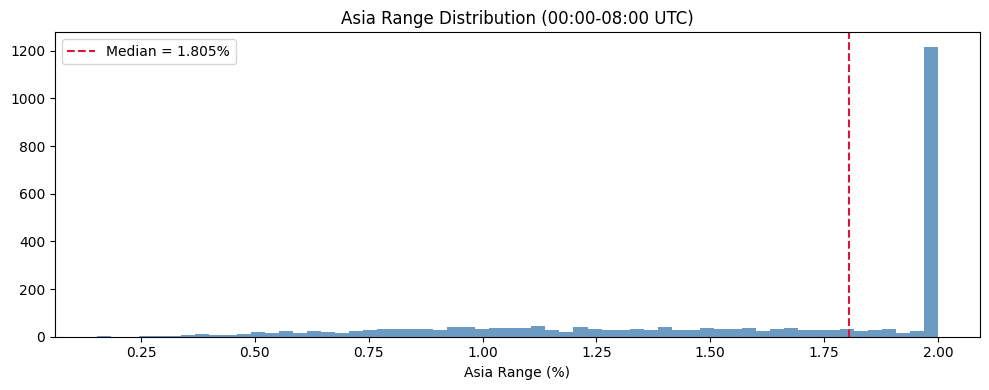

Saved: 05_asia_range.png
Cell 4 OK


In [4]:
# ── Per-day Asia range: 00:00–08:00 UTC ───────────────────────────────────────
asia_mask = (
    (df_raw['open_time'].dt.hour >= p['asia_start_utc']) &
    (df_raw['open_time'].dt.hour <  p['asia_end_utc'])
)
asia_candles = df_raw[asia_mask]

asia_df = (
    asia_candles
    .groupby('date')
    .agg(
        asia_high=('high',      'max'),
        asia_low=('low',        'min'),
        n_asia=('open_time',    'count'),
    )
    .reset_index()
)
asia_df['asia_range_pct'] = (
    (asia_df['asia_high'] - asia_df['asia_low']) / asia_df['asia_low'] * 100.0
)

print(f"Asia range computed for {len(asia_df):,} days")
print(f"Avg range:    {asia_df['asia_range_pct'].mean():.3f}%")
print(f"Median range: {asia_df['asia_range_pct'].median():.3f}%")
print(f"P10 / P90:    {asia_df['asia_range_pct'].quantile(0.10):.3f}% / {asia_df['asia_range_pct'].quantile(0.90):.3f}%")
print(f"\nExpected candles per Asia session: {asia_df['n_asia'].median():.0f} (96 = 8h full, less on weekends)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(asia_df['asia_range_pct'].clip(upper=2.0), bins=60, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(asia_df['asia_range_pct'].median(), color='crimson', ls='--', lw=1.5,
           label=f"Median = {asia_df['asia_range_pct'].median():.3f}%")
ax.set_title('Asia Range Distribution (00:00-08:00 UTC)')
ax.set_xlabel('Asia Range (%)'); ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_asia_range.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: 05_asia_range.png")
print("Cell 4 OK")

In [5]:
# ── Per-day break detection: 08:00–12:00 UTC ──────────────────────────────────
# Valid break requires: close displaced beyond Asia level + expansion candle.
# Expansion = candle_range > rolling_median AND volume > rolling_median.
break_mask = (
    (df_raw['open_time'].dt.hour >= p['break_start_utc']) &
    (df_raw['open_time'].dt.hour <  p['break_end_utc'])
)
break_candles = df_raw[break_mask].copy()
break_candles = break_candles.merge(
    asia_df[['date', 'asia_high', 'asia_low']], on='date', how='left'
)

buf = p['breakout_buffer_pct']
break_candles['is_long_break']  = (
    (break_candles['close'] > break_candles['asia_high'] * (1.0 + buf)) &
    break_candles['is_expansion']
)
break_candles['is_short_break'] = (
    (break_candles['close'] < break_candles['asia_low']  * (1.0 - buf)) &
    break_candles['is_expansion']
)

day_breaks = (
    break_candles.groupby('date')
    .agg(
        valid_long_break=('is_long_break',  'any'),
        valid_short_break=('is_short_break', 'any'),
    )
    .reset_index()
)

# Conflict: price broke both directions → ambiguous, skip
conflict = day_breaks['valid_long_break'] & day_breaks['valid_short_break']
day_breaks.loc[conflict, 'valid_long_break']  = False
day_breaks.loc[conflict, 'valid_short_break'] = False

# Join Asia levels back
day_breaks = day_breaks.merge(asia_df, on='date', how='left')

n_long_days  = int(day_breaks['valid_long_break'].sum())
n_short_days = int(day_breaks['valid_short_break'].sum())
n_conflict   = int(conflict.sum())
n_total_days = len(day_breaks)

print(f"Break detection across {n_total_days:,} days:")
print(f"  Valid LONG break:  {n_long_days:,} ({n_long_days/n_total_days*100:.1f}%)")
print(f"  Valid SHORT break: {n_short_days:,} ({n_short_days/n_total_days*100:.1f}%)")
print(f"  Conflict (skipped):{n_conflict:,} ({n_conflict/n_total_days*100:.1f}%)")
print(f"  No break:          {n_total_days - n_long_days - n_short_days - n_conflict:,} ({(n_total_days - n_long_days - n_short_days - n_conflict)/n_total_days*100:.1f}%)")
print(f"  Tradeable days:    {n_long_days + n_short_days:,} ({(n_long_days+n_short_days)/n_total_days*100:.1f}%)")
print("Cell 5 OK")

Break detection across 2,701 days:
  Valid LONG break:  624 (23.1%)
  Valid SHORT break: 599 (22.2%)
  Conflict (skipped):20 (0.7%)
  No break:          1,458 (54.0%)
  Tradeable days:    1,223 (45.3%)
Cell 5 OK


In [6]:
# ── Session data: 12:00–16:00 UTC + join break info ───────────────────────────
sess_mask = (
    (df_raw['open_time'].dt.hour >= p['session_start_utc']) &
    (df_raw['open_time'].dt.hour <  p['session_end_utc'])
)
df = df_raw[sess_mask].copy().reset_index(drop=True)

# Join daily break info
df = df.merge(
    day_breaks[['date', 'valid_long_break', 'valid_short_break',
                'asia_high', 'asia_low', 'asia_range_pct']],
    on='date', how='left'
)

# Session candle number within each day (0-indexed)
df['session_candle_num'] = df.groupby('date').cumcount()

tol = p['retest_tolerance_pct']
mc  = p['max_retest_candles']

# ── Retest conditions (same detection logic as Exp04) ────────────────────────
# retest_long  = long break day  + price touched Asia HIGH (Exp04 continuation long setup)
# retest_short = short break day + price touched Asia LOW  (Exp04 continuation short setup)
# Exp05A FADE: long_break+retest_high -> SHORT; short_break+retest_low -> LONG
df['retest_long']  = (
    df['valid_long_break'].fillna(False) &
    (df['session_candle_num'] < mc) &
    (df['low']   <= df['asia_high'] * (1.0 + tol)) &
    (df['close']  > df['asia_high'] * (1.0 - tol))
)
df['retest_short'] = (
    df['valid_short_break'].fillna(False) &
    (df['session_candle_num'] < mc) &
    (df['high']  >= df['asia_low']  * (1.0 - tol)) &
    (df['close']  < df['asia_low']  * (1.0 + tol))
)

# ── Anti-leakage: shift within day (no cross-day bleed) ───────────────────────
# EXP05A: INVERT DIRECTION — fade the breakout
# LONG after a SHORT break retest (fade down-move, expect reversal up)
# SHORT after a LONG break retest (fade up-move, expect reversal down)
df['signal_long']  = df.groupby('date')['retest_short'].shift(1).fillna(False)
df['signal_short'] = df.groupby('date')['retest_long'].shift(1).fillna(False)

n_long  = int(df['signal_long'].sum())
n_short = int(df['signal_short'].sum())
print(f"Session candles (12-16 UTC): {len(df):,}")
print(f"LONG signals:  {n_long:,}")
print(f"SHORT signals: {n_short:,}")
print(f"Total:         {n_long + n_short:,}")
print(f"Signal rate:   {(n_long + n_short) / len(df) * 100:.2f}% of session candles")

days_with_sig = df[df['signal_long'] | df['signal_short']]['date'].nunique()
print(f"Days with signal: {days_with_sig:,} / {df['date'].nunique():,} ({days_with_sig/df['date'].nunique()*100:.1f}%)")
print("Cell 6 OK — FADE signals: signal_long<-retest_short, signal_short<-retest_long")

Session candles (12-16 UTC): 129,594
LONG signals:  969
SHORT signals: 1,118
Total:         2,087
Signal rate:   1.61% of session candles
Days with signal: 552 / 2,701 (20.4%)
Cell 6 OK — FADE signals: signal_long<-retest_short, signal_short<-retest_long


In [7]:
# ── Signal diagnostics ─────────────────────────────────────────────────────────
if n_long + n_short > 0:
    sig_df = df[df['signal_long'] | df['signal_short']].copy()
    print("Retest candle timing (session_candle_num at signal, 0=first candle of session):")
    timing = sig_df['session_candle_num'].value_counts().sort_index()
    print(timing.head(mc + 2).to_string())
    print(f"\nMean candle: {sig_df['session_candle_num'].mean():.1f}  "
          f"Median: {sig_df['session_candle_num'].median():.1f}")

print("\nYearly signal distribution:")
df['year'] = df['open_time'].dt.year
for yr in sorted(df['year'].unique()):
    yr_df = df[df['year'] == yr]
    n_s = int((yr_df['signal_long'] | yr_df['signal_short']).sum())
    n_c = len(yr_df)
    print(f"  {yr}: {n_s:4d} signals  ({n_s/n_c*100:.2f}%)")

print("\nDirection split:")
print(f"  LONG:  {n_long:,} ({n_long/(n_long+n_short)*100:.1f}%)" if n_long+n_short else "  No signals")
print(f"  SHORT: {n_short:,} ({n_short/(n_long+n_short)*100:.1f}%)" if n_long+n_short else "")
print("Cell 7 OK")

Retest candle timing (session_candle_num at signal, 0=first candle of session):
session_candle_num
1     187
2     200
3     186
4     192
5     191
6     166
7     187
8     159
9     160
10    165
11    143
12    151

Mean candle: 6.2  Median: 6.0

Yearly signal distribution:
  2019:  250 signals  (1.43%)
  2020:  309 signals  (1.77%)
  2021:  267 signals  (1.52%)
  2022:  279 signals  (1.59%)
  2023:  282 signals  (1.61%)
  2024:  262 signals  (1.49%)
  2025:  311 signals  (1.78%)
  2026:  127 signals  (1.82%)

Direction split:
  LONG:  969 (46.4%)
  SHORT: 1,118 (53.6%)
Cell 7 OK


In [8]:
# ── Train / Hold-out split — 70/30 temporal ────────────────────────────────────
# Same split as Exp 03 for consistency (same dataset, same holdout period).
SPLIT_DATE = pd.Timestamp('2024-03-07', tz='UTC')

df['split'] = 'train'
df.loc[df['open_time'] >= SPLIT_DATE, 'split'] = 'holdout'

n_train   = (df['split'] == 'train').sum()
n_holdout = (df['split'] == 'holdout').sum()
print(f"Train candles:   {n_train:,}  ({n_train/(n_train+n_holdout)*100:.1f}%)")
print(f"Holdout candles: {n_holdout:,}  ({n_holdout/(n_train+n_holdout)*100:.1f}%)")
print(f"Train end:     {df[df['split']=='train']['open_time'].max()}")
print(f"Holdout start: {df[df['split']=='holdout']['open_time'].min()}")

# Signal count by split
sig_train   = df[df['split']=='train']
sig_holdout = df[df['split']=='holdout']
print(f"\nSignals — train: {int((sig_train['signal_long']|sig_train['signal_short']).sum()):,}  "
      f"holdout: {int((sig_holdout['signal_long']|sig_holdout['signal_short']).sum()):,}")
print("Cell 8 OK")

Train candles:   90,714  (70.0%)
Holdout candles: 38,880  (30.0%)
Train end:     2024-03-06 15:55:00+00:00
Holdout start: 2024-03-07 12:00:00+00:00

Signals — train: 1,434  holdout: 653
Cell 8 OK


In [9]:
# ── Backtest ───────────────────────────────────────────────────────────────────
def run_backtest(df: pd.DataFrame, params: dict, spec_hash: str) -> pd.DataFrame:
    p = params
    records = []

    opens    = df['open'].values
    highs    = df['high'].values
    lows     = df['low'].values
    closes   = df['close'].values
    times    = df['open_time'].values
    sig_l    = df['signal_long'].values
    sig_s    = df['signal_short'].values
    sp_p80   = df['spread_p80'].values
    splits   = df['split'].values
    asia_h   = df['asia_high'].values
    asia_l   = df['asia_low'].values
    asia_r   = df['asia_range_pct'].values
    sc_num   = df['session_candle_num'].values

    in_pos = False; trade_id = 0
    direction = entry_price = sl_price = tp_price = entry_time = entry_date = None
    candles_held = 0; mae = mfe = 0.0
    spread_at_entry = 0.0
    split_at_entry = entry_month = ''
    asia_h_e = asia_l_e = asia_r_e = 0.0
    sc_e = 0

    for i in range(len(df)):
        t = pd.Timestamp(times[i])

        if in_pos:
            candles_held += 1
            h, l, c = highs[i], lows[i], closes[i]
            is_cross_day = (t.date() != entry_date)
            is_eod       = (t.hour == 15 and t.minute >= 55)

            if direction == 'LONG':
                adverse   = (l - entry_price) / entry_price
                favorable = (h - entry_price) / entry_price
            else:
                adverse   = (entry_price - h) / entry_price
                favorable = (entry_price - l) / entry_price
            mae = min(mae, adverse)
            mfe = max(mfe, favorable)

            exit_price = exit_reason = None
            if direction == 'LONG':
                if l <= sl_price:
                    exit_price, exit_reason = sl_price, 'SL'
                elif h >= tp_price:
                    exit_price, exit_reason = tp_price, 'TP'
                elif candles_held >= p['max_holding_candles']:
                    exit_price, exit_reason = c, 'MAX_HOLD'
                elif is_eod or is_cross_day:
                    exit_price, exit_reason = c, 'EOD'
            else:
                if h >= sl_price:
                    exit_price, exit_reason = sl_price, 'SL'
                elif l <= tp_price:
                    exit_price, exit_reason = tp_price, 'TP'
                elif candles_held >= p['max_holding_candles']:
                    exit_price, exit_reason = c, 'MAX_HOLD'
                elif is_eod or is_cross_day:
                    exit_price, exit_reason = c, 'EOD'

            if exit_price is not None:
                pnl_gross  = ((exit_price - entry_price) / entry_price
                              if direction == 'LONG'
                              else (entry_price - exit_price) / entry_price)
                fees_pct   = p['taker_fee_per_side'] * 2.0
                cost_total = fees_pct + spread_at_entry
                records.append({
                    'trade_id':           trade_id,
                    'entry_time':         pd.Timestamp(entry_time),
                    'exit_time':          t,
                    'direction':          direction,
                    'entry_price':        float(entry_price),
                    'exit_price':         float(exit_price),
                    'exit_reason':        exit_reason,
                    'holding_candles':    candles_held,
                    'spread_pct':         float(spread_at_entry),
                    'fees_pct':           float(fees_pct),
                    'cost_total_pct':     float(cost_total),
                    'pnl_gross_pct':      float(pnl_gross),
                    'pnl_net_pct':        float(pnl_gross - cost_total),
                    'mae_pct':            float(abs(mae)),
                    'mfe_pct':            float(mfe),
                    'asia_high':          float(asia_h_e),
                    'asia_low':           float(asia_l_e),
                    'asia_range_pct':     float(asia_r_e),
                    'session_candle_num': int(sc_e),
                    'split':              split_at_entry,
                    'month':              entry_month,
                    'spec_hash':          spec_hash,
                })
                in_pos = False; trade_id += 1

        else:
            direction_new = 'LONG' if sig_l[i] else ('SHORT' if sig_s[i] else None)
            if direction_new is not None:
                if t.hour == 15 and t.minute >= 55:
                    continue
                sp = float(sp_p80[i]) if not np.isnan(sp_p80[i]) else 0.00015
                in_pos          = True
                direction       = direction_new
                entry_price     = opens[i]
                entry_time      = times[i]
                entry_date      = t.date()
                candles_held    = 0
                mae = mfe       = 0.0
                spread_at_entry = sp
                split_at_entry  = splits[i]
                entry_month     = t.strftime('%Y-%m')
                asia_h_e        = float(asia_h[i]) if not np.isnan(asia_h[i]) else 0.0
                asia_l_e        = float(asia_l[i]) if not np.isnan(asia_l[i]) else 0.0
                asia_r_e        = float(asia_r[i]) if not np.isnan(asia_r[i]) else 0.0
                sc_e            = int(sc_num[i])
                if direction == 'LONG':
                    sl_price = entry_price * (1.0 - p['sl_pct'])
                    tp_price = entry_price * (1.0 + p['tp_pct'])
                else:
                    sl_price = entry_price * (1.0 + p['sl_pct'])
                    tp_price = entry_price * (1.0 - p['tp_pct'])

    return pd.DataFrame(records)


print("Running backtest...")
trades = run_backtest(df, FROZEN_PARAMS, SPEC_HASH)
print(f"Total trades: {len(trades):,}")
if len(trades):
    print(f"  Train:   {(trades['split']=='train').sum():,}")
    print(f"  Holdout: {(trades['split']=='holdout').sum():,}")
    print(f"\nExit distribution:")
    print(trades['exit_reason'].value_counts().to_string())
    print(f"\nDirection split:")
    print(trades['direction'].value_counts().to_string())
else:
    print("WARNING: 0 trades. Check retest_tolerance, breakout_buffer, max_retest_candles.")

Running backtest...
Total trades: 882
  Train:   636
  Holdout: 246

Exit distribution:
exit_reason
SL          593
TP          277
MAX_HOLD     12

Direction split:
direction
SHORT    451
LONG     431


In [10]:
# ── Equity Curve ───────────────────────────────────────────────────────────────
def compute_equity_curve(t: pd.DataFrame, capital: float) -> pd.DataFrame:
    t = t.sort_values('exit_time').copy().reset_index(drop=True)
    t['cumulative_pnl_pct']   = t['pnl_net_pct'].cumsum()
    t['equity_usdt']          = capital * (1.0 + t['cumulative_pnl_pct'])
    t['peak_equity']          = t['equity_usdt'].cummax()
    t['rolling_drawdown_pct'] = (t['equity_usdt'] - t['peak_equity']) / t['peak_equity'] * 100.0
    count, streak = [], 0
    for v in (t['equity_usdt'] < t['peak_equity']).values:
        streak = streak + 1 if v else 0
        count.append(streak)
    t['underwater_trades'] = count
    return t


if len(trades) == 0:
    print("No trades — skip."); equity_all = equity_train = equity_hold = pd.DataFrame()
else:
    equity_all   = compute_equity_curve(trades,                             FROZEN_PARAMS['capital_usdt'])
    equity_train = compute_equity_curve(trades[trades['split']=='train'],   FROZEN_PARAMS['capital_usdt'])
    equity_hold  = compute_equity_curve(trades[trades['split']=='holdout'], FROZEN_PARAMS['capital_usdt'])

    for label, eq in [('train', equity_train), ('holdout', equity_hold)]:
        if len(eq):
            print(f"{label:8s}  total_return={eq['cumulative_pnl_pct'].iloc[-1]*100:+.2f}%"
                  f"  max_dd={eq['rolling_drawdown_pct'].min():.2f}%"
                  f"  peak={eq['peak_equity'].max():.0f} USDT")

    equity_all.to_csv(OUTPUT_DIR / '05_equity.csv', index=False)
    print("\nSaved: outputs/05_equity.csv")

train     total_return=-50.07%  max_dd=-50.57%  peak=10003 USDT
holdout   total_return=-16.39%  max_dd=-16.98%  peak=10035 USDT

Saved: outputs/05_equity.csv


In [11]:
# ── Aggregate Metrics ─────────────────────────────────────────────────────────
def compute_expectancy(pnl: pd.Series) -> float:
    if len(pnl) == 0: return 0.0
    wins   = pnl[pnl > 0]
    losses = pnl[pnl <= 0]
    wr     = len(wins) / len(pnl)
    return wr * (wins.mean() if len(wins) else 0.0) - (1 - wr) * (losses.abs().mean() if len(losses) else 0.0)


def summary_metrics(t: pd.DataFrame, label: str) -> dict:
    if len(t) == 0: return {'split': label, 'n_trades': 0}
    pnl  = t['pnl_net_pct']
    wins = pnl[pnl > 0]; loss = pnl[pnl <= 0]; wr = len(wins) / len(pnl)
    eq   = compute_equity_curve(t, FROZEN_PARAMS['capital_usdt'])
    return {
        'split':                  label,
        'n_trades':               len(t),
        'win_rate':               round(wr, 4),
        'breakeven_wr':           round((FROZEN_PARAMS['sl_pct'] + FROZEN_PARAMS['taker_fee_per_side']*2)
                                        / (FROZEN_PARAMS['sl_pct'] + FROZEN_PARAMS['tp_pct']), 3),
        'avg_win_net_pct':        round(wins.mean() * 100,       4) if len(wins) else 0.0,
        'avg_loss_net_pct':       round(loss.abs().mean() * 100, 4) if len(loss) else 0.0,
        'expectancy_net_pct':     round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct':       round(pnl.sum() * 100, 2),
        'max_drawdown_pct':       round(eq['rolling_drawdown_pct'].min(), 2),
        'sharpe_ref':             round(pnl.mean() / pnl.std() if pnl.std() > 0 else 0.0, 3),
        'avg_mae_pct':            round(t['mae_pct'].mean() * 100, 4),
        'avg_mfe_pct':            round(t['mfe_pct'].mean() * 100, 4),
        'avg_holding_candles':    round(t['holding_candles'].mean(), 1),
        'pct_tp':                 round((t['exit_reason']=='TP').mean() * 100,       1),
        'pct_sl':                 round((t['exit_reason']=='SL').mean() * 100,       1),
        'pct_max_hold':           round((t['exit_reason']=='MAX_HOLD').mean() * 100, 1),
        'pct_eod':                round((t['exit_reason']=='EOD').mean() * 100,      1),
        'avg_session_candle_num': round(t['session_candle_num'].mean(), 1),
        'avg_asia_range_pct':     round(t['asia_range_pct'].mean(), 3),
    }


train_metrics   = summary_metrics(trades[trades['split']=='train'],   'train')
holdout_metrics = summary_metrics(trades[trades['split']=='holdout'], 'holdout')

mdf = pd.DataFrame([train_metrics, holdout_metrics]).set_index('split').T
print(mdf.to_string())

# ── Per-month breakdown ───────────────────────────────────────────────────────
monthly_rows = []
for (split, month), g in trades.groupby(['split', 'month']):
    pnl = g['pnl_net_pct']
    monthly_rows.append({
        'split': split, 'month': month, 'n_trades': len(g),
        'win_rate':         round((pnl > 0).mean(), 3),
        'expectancy_pct':   round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct': round(pnl.sum() * 100, 2),
    })
monthly = pd.DataFrame(monthly_rows).sort_values(['split', 'month']) if monthly_rows else pd.DataFrame()
print("\n── Per-month breakdown ──────────────────────────────────────────────")
print(monthly.to_string(index=False) if len(monthly) else "No trades")

# ── Asia range context at entry ───────────────────────────────────────────────
if len(trades):
    print("\n── Asia range percentile at entry ───────────────────────────────────")
    trades['asia_range_bucket'] = pd.qcut(
        trades['asia_range_pct'], q=4, labels=['Q1 (tight)', 'Q2', 'Q3', 'Q4 (wide)']
    )
    ar_analysis = trades.groupby('asia_range_bucket')['pnl_net_pct'].agg(
        n='count', wr=lambda x: (x > 0).mean(), e_net=lambda x: compute_expectancy(x) * 100
    ).round(4)
    print(ar_analysis.to_string())

split                      train   holdout
n_trades                636.0000  246.0000
win_rate                  0.3097    0.3374
breakeven_wr              0.4600    0.4600
avg_win_net_pct           0.2650    0.2593
avg_loss_net_pct          0.2330    0.2326
expectancy_net_pct       -0.0787   -0.0666
total_return_pct        -50.0700  -16.3900
max_drawdown_pct        -50.5700  -16.9800
sharpe_ref               -0.3410   -0.2840
avg_mae_pct               0.2499    0.1894
avg_mfe_pct               0.2617    0.2424
avg_holding_candles       3.7000    5.4000
pct_tp                   31.0000   32.5000
pct_sl                   68.1000   65.0000
pct_max_hold              0.9000    2.4000
pct_eod                   0.0000    0.0000
avg_session_candle_num    5.3000    5.2000
avg_asia_range_pct        2.7160    1.9040

── Per-month breakdown ──────────────────────────────────────────────
  split   month  n_trades  win_rate  expectancy_pct  total_return_pct
holdout 2024-03        15     0.333       

In [12]:
# ── Block Bootstrap CI on E_net ───────────────────────────────────────────────
# BOOTSTRAP_BLOCK=4 M5 = 20min temporal equiv.
BOOTSTRAP_N = 1000

def block_bootstrap_expectancy(pnl: pd.Series, n_iter=BOOTSTRAP_N,
                                block_size=BOOTSTRAP_BLOCK, seed=42) -> tuple:
    rng = np.random.default_rng(seed)
    arr = pnl.values; n = len(arr)
    results = []
    for _ in range(n_iter):
        idx = []
        while len(idx) < n:
            start = int(rng.integers(0, max(1, n - block_size)))
            idx.extend(range(start, min(start + block_size, n)))
        results.append(compute_expectancy(pd.Series(arr[idx[:n]])))
    lo, hi = np.percentile(results, [2.5, 97.5])
    return lo, hi, np.array(results)


train_pnl   = trades[trades['split']=='train']['pnl_net_pct']
holdout_pnl = trades[trades['split']=='holdout']['pnl_net_pct']

if len(train_pnl) < 20 or len(holdout_pnl) < 20:
    print("WARNING: insufficient trades for bootstrap — point estimates only")
    ci_lo_hold = ci_hi_hold = compute_expectancy(holdout_pnl)
    _boot_hold = np.array([ci_lo_hold])
else:
    ci_lo_train, ci_hi_train, _ = block_bootstrap_expectancy(train_pnl)
    ci_lo_hold,  ci_hi_hold,  _boot_hold = block_bootstrap_expectancy(holdout_pnl)
    print(f"Train   E_net: {compute_expectancy(train_pnl)*100:+.4f}%   95% CI: [{ci_lo_train*100:.4f}%, {ci_hi_train*100:.4f}%]")

print(f"Holdout E_net: {compute_expectancy(holdout_pnl)*100:+.4f}%   95% CI: [{ci_lo_hold*100:.4f}%,  {ci_hi_hold*100:.4f}%]")
holdout_metrics['expectancy_ci_95_lo_pct'] = round(ci_lo_hold * 100, 4)
holdout_metrics['expectancy_ci_95_hi_pct'] = round(ci_hi_hold * 100, 4)
print(f"Cell 12 OK — BOOTSTRAP_BLOCK={BOOTSTRAP_BLOCK} (20min temporal equiv.)")

Train   E_net: -0.0787%   95% CI: [-0.0963%, -0.0627%]
Holdout E_net: -0.0666%   95% CI: [-0.0971%,  -0.0425%]
Cell 12 OK — BOOTSTRAP_BLOCK=4 (20min temporal equiv.)


In [13]:
# ── Direction-Aware Baseline Monte Carlo ──────────────────────────────────────
def direction_aware_baseline(df_full, train_trades, params, n_sims=1000, seed=42):
    rng        = np.random.default_rng(seed)
    p          = params
    n          = len(train_trades)
    if n == 0: return np.zeros(n_sims)
    long_ratio = (train_trades['direction'] == 'LONG').mean()
    sess       = df_full[df_full['split'] == 'train'].reset_index(drop=True)
    max_idx    = len(sess) - p['max_holding_candles'] - 2
    if max_idx <= 0: return np.zeros(n_sims)

    e_sims = []
    for _ in range(n_sims):
        entries    = rng.integers(0, max_idx, size=n)
        directions = rng.choice(['LONG', 'SHORT'], size=n, p=[long_ratio, 1 - long_ratio])
        pnl_sim    = []
        for idx, dirn in zip(entries, directions):
            ep   = sess['open'].iloc[idx]
            sp   = float(sess['spread_p80'].iloc[idx])
            if np.isnan(sp): sp = 0.00015
            cost = p['taker_fee_per_side'] * 2.0 + sp
            sl_p = ep * (1 - p['sl_pct']) if dirn == 'LONG' else ep * (1 + p['sl_pct'])
            tp_p = ep * (1 + p['tp_pct']) if dirn == 'LONG' else ep * (1 - p['tp_pct'])
            exit_pnl = None
            for k in range(1, p['max_holding_candles'] + 1):
                if idx + k >= len(sess): break
                h  = sess['high'].iloc[idx + k]; l  = sess['low'].iloc[idx + k]
                c  = sess['close'].iloc[idx + k]; tk = sess['open_time'].iloc[idx + k]
                eod = (tk.hour == 15 and tk.minute >= 55)
                if dirn == 'LONG':
                    if l <= sl_p: exit_pnl = (sl_p-ep)/ep - cost; break
                    elif h >= tp_p: exit_pnl = (tp_p-ep)/ep - cost; break
                    elif k == p['max_holding_candles'] or eod: exit_pnl = (c-ep)/ep - cost; break
                else:
                    if h >= sl_p: exit_pnl = (ep-sl_p)/ep - cost; break
                    elif l <= tp_p: exit_pnl = (ep-tp_p)/ep - cost; break
                    elif k == p['max_holding_candles'] or eod: exit_pnl = (ep-c)/ep - cost; break
            pnl_sim.append(exit_pnl if exit_pnl is not None else -cost)
        e_sims.append(compute_expectancy(pd.Series(pnl_sim)))
    return np.array(e_sims)


print("Running direction-aware baseline (1000 sims)... ~60-120s")
baseline_dist  = direction_aware_baseline(df, trades[trades['split']=='train'], FROZEN_PARAMS)
baseline_p95   = float(np.percentile(baseline_dist, 95))
strategy_e_net = compute_expectancy(holdout_pnl)

print(f"Baseline P95:          {baseline_p95*100:+.4f}%")
print(f"Strategy E_net (hold): {strategy_e_net*100:+.4f}%")
print(f"Strategy > P95:        {strategy_e_net > baseline_p95}")

np.savetxt(OUTPUT_DIR / '05_baseline_dist.csv', baseline_dist * 100,
           delimiter=',', header='baseline_e_net_pct', comments='')
print("Saved: outputs/05_baseline_dist.csv")

Running direction-aware baseline (1000 sims)... ~60-120s
Baseline P95:          -0.0546%
Strategy E_net (hold): -0.0666%
Strategy > P95:        False
Saved: outputs/05_baseline_dist.csv


In [14]:
# ── Session Characteristics Analysis ──────────────────────────────────────────
# Key question: does the structural quality of the Asia range + break
# predict trade outcome? Metrics: range size, entry timing, direction.

if len(trades) >= 20:
    print("── Asia range size vs outcome ──────────────────────────────────────")
    print(trades.groupby('asia_range_bucket')['pnl_net_pct'].agg(
        n='count',
        wr=lambda x: f"{(x > 0).mean()*100:.1f}%",
        e_net=lambda x: f"{compute_expectancy(x)*100:+.4f}%",
        avg_mfe=lambda x: f"{trades.loc[x.index,'mfe_pct'].mean()*100:.4f}%",
        avg_mae=lambda x: f"{trades.loc[x.index,'mae_pct'].mean()*100:.4f}%",
    ).to_string())

    print("\n── Entry timing vs outcome ──────────────────────────────────────────")
    timing_analysis = trades.groupby('session_candle_num')['pnl_net_pct'].agg(
        n='count', wr=lambda x: (x > 0).mean(), e_net=lambda x: compute_expectancy(x) * 100
    ).round(4)
    print(timing_analysis.head(13).to_string())

    print("\n── Direction vs outcome ─────────────────────────────────────────────")
    print(trades.groupby('direction')['pnl_net_pct'].agg(
        n='count', wr=lambda x: round((x > 0).mean(), 3),
        e_net=lambda x: round(compute_expectancy(x) * 100, 4)
    ).to_string())
else:
    print("Insufficient trades for breakdown analysis.")

print("Cell 14 OK")

── Asia range size vs outcome ──────────────────────────────────────
                     n     wr     e_net  avg_mfe  avg_mae
asia_range_bucket                                        
Q1 (tight)         222  35.1%  -0.0552%  0.2232%  0.1749%
Q2                 219  32.9%  -0.0711%  0.2324%  0.1957%
Q3                 220  25.5%  -0.1077%  0.2325%  0.2548%
Q4 (wide)          221  33.5%  -0.0676%  0.3370%  0.3067%

── Entry timing vs outcome ──────────────────────────────────────────
                      n      wr   e_net
session_candle_num                     
1                   187  0.3422 -0.0601
2                    91  0.2527 -0.1130
3                    62  0.3871 -0.0415
4                    81  0.2840 -0.0899
5                    71  0.2394 -0.1136
6                    55  0.2909 -0.0895
7                    80  0.3875 -0.0413
8                    50  0.2800 -0.0950
9                    48  0.2917 -0.0866
10                   61  0.3934 -0.0383
11                   48  0.3125 

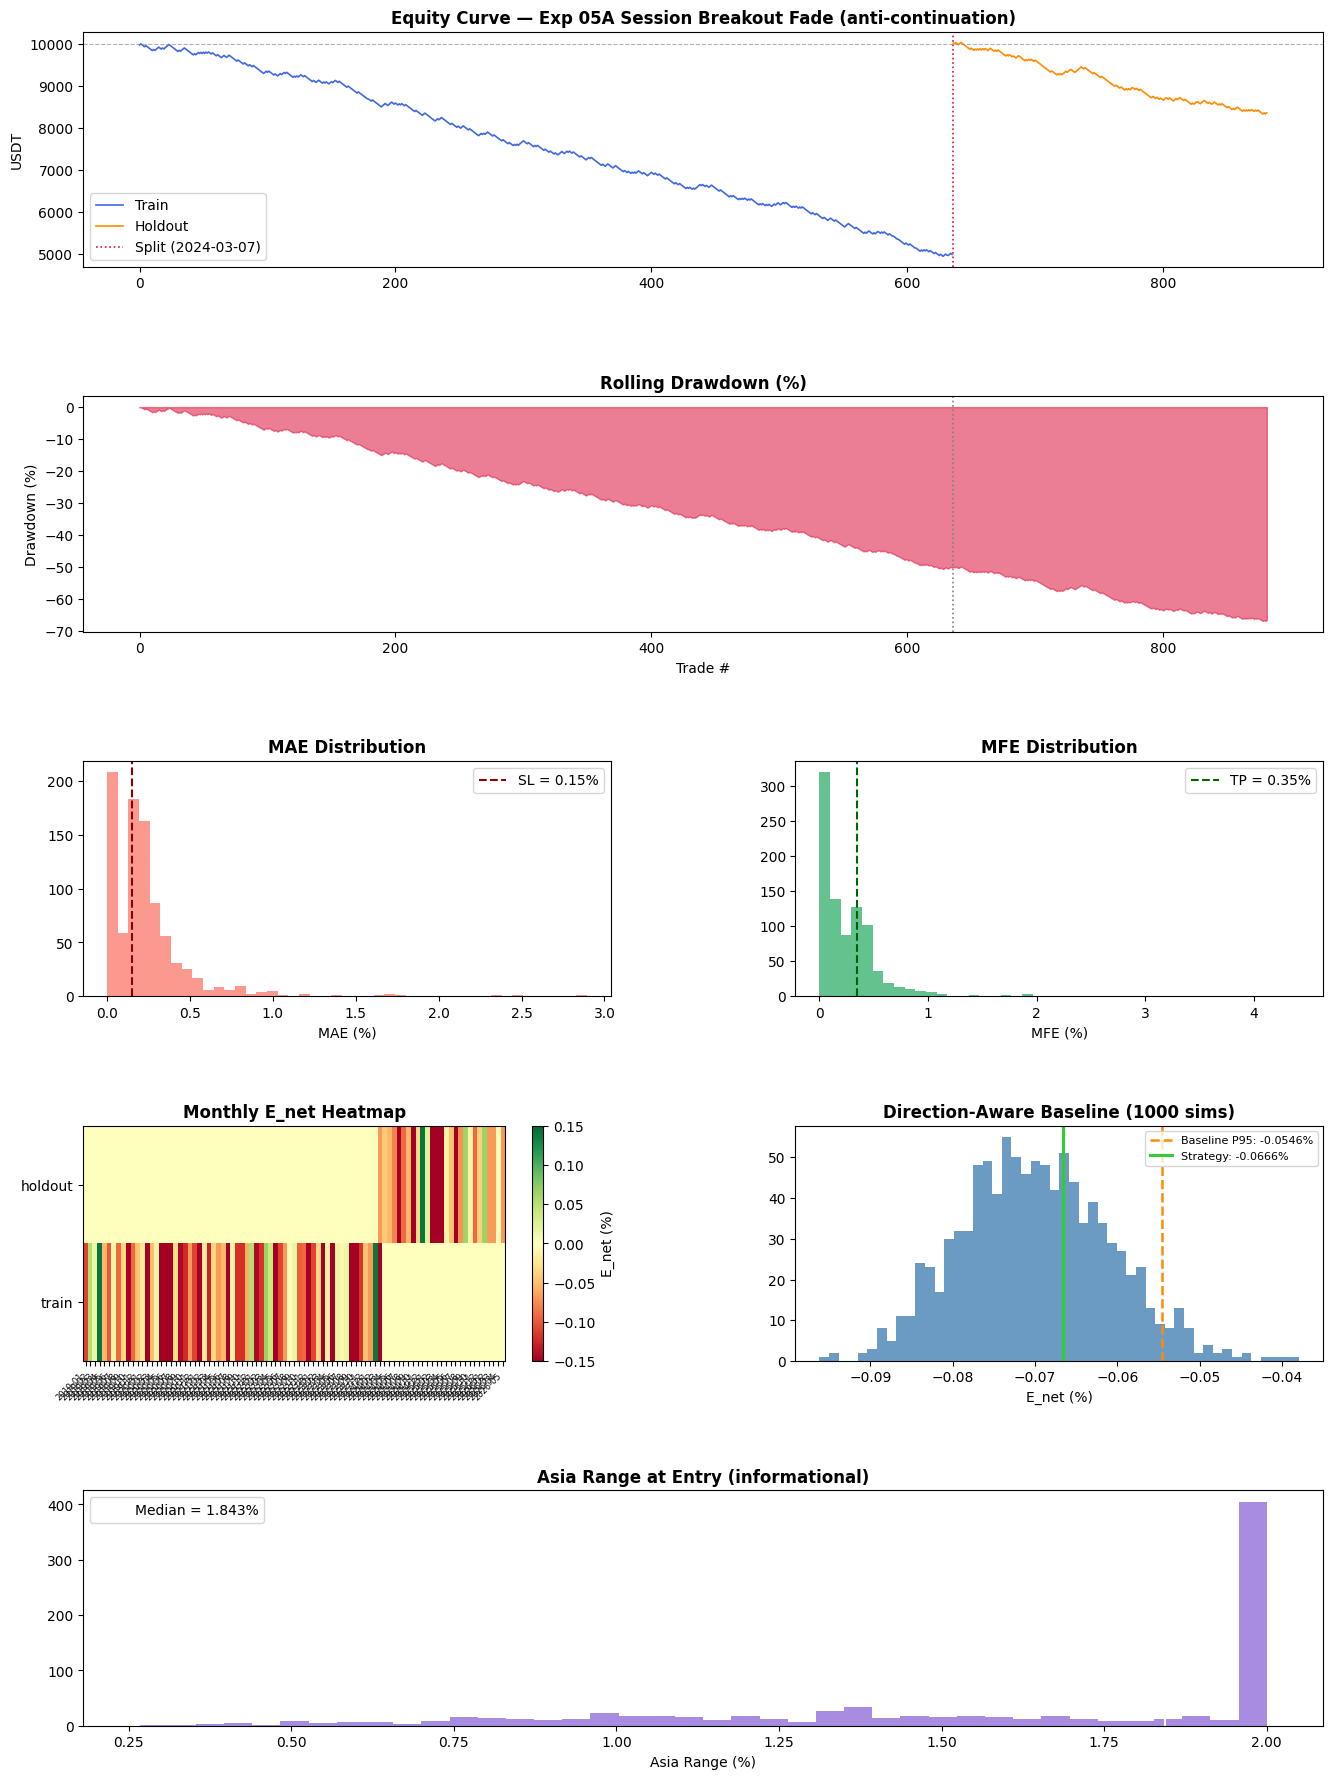

Saved: outputs/05_visualizations.png


In [15]:
# ── Visualizations ─────────────────────────────────────────────────────────────
if len(equity_all) == 0:
    print("No trades — skip visualizations")
else:
    fig = plt.figure(figsize=(16, 22))
    gs  = GridSpec(5, 2, figure=fig, hspace=0.55, wspace=0.35)

    # Equity curve
    ax1 = fig.add_subplot(gs[0, :])
    if len(equity_train):
        ax1.plot(range(len(equity_train)), equity_train['equity_usdt'],
                 color='royalblue', lw=1.2, label='Train')
    if len(equity_hold):
        ax1.plot(range(len(equity_train), len(equity_train)+len(equity_hold)),
                 equity_hold['equity_usdt'], color='darkorange', lw=1.2, label='Holdout')
    ax1.axhline(FROZEN_PARAMS['capital_usdt'], color='gray', ls='--', lw=0.8, alpha=0.6)
    ax1.axvline(len(equity_train), color='crimson', ls=':', lw=1.2, label='Split (2024-03-07)')
    ax1.set_title('Equity Curve — Exp 05A Session Breakout Fade (anti-continuation)', fontweight='bold')
    ax1.set_ylabel('USDT'); ax1.legend()

    # Drawdown
    ax2 = fig.add_subplot(gs[1, :])
    ax2.fill_between(range(len(equity_all)), equity_all['rolling_drawdown_pct'], 0,
                     alpha=0.55, color='crimson')
    ax2.axvline(len(equity_train), color='gray', ls=':', lw=1.2)
    ax2.set_title('Rolling Drawdown (%)', fontweight='bold')
    ax2.set_ylabel('Drawdown (%)'); ax2.set_xlabel('Trade #')

    # MAE
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.hist(trades['mae_pct'] * 100, bins=45, color='salmon', edgecolor='none', alpha=0.8)
    ax3.axvline(FROZEN_PARAMS['sl_pct'] * 100, color='darkred', ls='--', lw=1.5,
                label=f"SL = {FROZEN_PARAMS['sl_pct']*100:.2f}%")
    ax3.set_title('MAE Distribution', fontweight='bold'); ax3.set_xlabel('MAE (%)'); ax3.legend()

    # MFE
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.hist(trades['mfe_pct'] * 100, bins=45, color='mediumseagreen', edgecolor='none', alpha=0.8)
    ax4.axvline(FROZEN_PARAMS['tp_pct'] * 100, color='darkgreen', ls='--', lw=1.5,
                label=f"TP = {FROZEN_PARAMS['tp_pct']*100:.2f}%")
    ax4.set_title('MFE Distribution', fontweight='bold'); ax4.set_xlabel('MFE (%)'); ax4.legend()

    # Monthly heatmap
    ax5 = fig.add_subplot(gs[3, 0])
    if len(monthly) > 0:
        try:
            mp = monthly.pivot(index='split', columns='month', values='expectancy_pct').fillna(0)
            im = ax5.imshow(mp.values, aspect='auto', cmap='RdYlGn', vmin=-0.15, vmax=0.15)
            ax5.set_xticks(range(len(mp.columns)))
            ax5.set_xticklabels(mp.columns, rotation=45, ha='right', fontsize=6)
            ax5.set_yticks(range(len(mp.index))); ax5.set_yticklabels(mp.index)
            plt.colorbar(im, ax=ax5, label='E_net (%)')
        except Exception as e:
            ax5.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Monthly E_net Heatmap', fontweight='bold')

    # Baseline
    ax6 = fig.add_subplot(gs[3, 1])
    ax6.hist(baseline_dist * 100, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax6.axvline(baseline_p95 * 100, color='darkorange', ls='--', lw=1.8,
                label=f'Baseline P95: {baseline_p95*100:.4f}%')
    ax6.axvline(strategy_e_net * 100, color='limegreen', ls='-', lw=2.2,
                label=f'Strategy: {strategy_e_net*100:.4f}%')
    ax6.set_title('Direction-Aware Baseline (1000 sims)', fontweight='bold')
    ax6.set_xlabel('E_net (%)'); ax6.legend(fontsize=8)

    # Asia range distribution (new for Exp04)
    ax7 = fig.add_subplot(gs[4, :])
    ax7.hist(trades['asia_range_pct'].clip(upper=2.0), bins=40,
             color='mediumpurple', edgecolor='none', alpha=0.8)
    ax7.axvline(trades['asia_range_pct'].median(), color='white', ls='--', lw=1.5,
                label=f"Median = {trades['asia_range_pct'].median():.3f}%")
    ax7.set_title('Asia Range at Entry (informational)', fontweight='bold')
    ax7.set_xlabel('Asia Range (%)'); ax7.legend()

    plt.savefig(OUTPUT_DIR / '05_visualizations.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: outputs/05_visualizations.png")

In [16]:
# ── Go / No-Go Decision Table ──────────────────────────────────────────────────
e_net_hold = compute_expectancy(holdout_pnl)
n_hold     = len(trades[trades['split']=='holdout'])
ci_lo      = holdout_metrics.get('expectancy_ci_95_lo_pct', 0) / 100

required = {
    'E_net > 0':                      e_net_hold > 0,
    'n_trades >= 100':                n_hold >= 100,
    'CI_95_lower > -0.02%':           ci_lo > -0.0002,
    'strategy_E_net > baseline_P95':  strategy_e_net > baseline_p95,
}

e_train_val      = compute_expectancy(train_pnl)
_holdout_monthly = monthly[monthly['split'] == 'holdout'] if len(monthly) else pd.DataFrame()
advisory = {
    'train->holdout degradation < 50%': (
        abs(e_train_val - e_net_hold) / abs(e_train_val) < 0.5
        if abs(e_train_val) > 1e-9 else False
    ),
    'monthly E_net positive >= 6/12 (holdout only)': (
        int((_holdout_monthly['expectancy_pct'] > 0).sum()) >= 6
        if len(_holdout_monthly) > 0 else False
    ),
    'max_drawdown < 20%': (
        equity_all['rolling_drawdown_pct'].min() > -20.0 if len(equity_all) else False
    ),
    'win_rate > 55%': (
        (trades['pnl_net_pct'] > 0).mean() > 0.55 if len(trades) else False
    ),
}

all_pass = all(required.values())
verdict  = 'GO' if all_pass else 'NO-GO'

SEP = '=' * 60
print(SEP)
print(f"  EXPERIMENT 05A — SESSION BREAKOUT FADE (anti-continuation)")
print(f"  Dataset: BTCUSDT M5, 2019-01-01 → 2026-05-25")
print(f"  SPEC_HASH : {SPEC_HASH}")
print(f"  VERDICT   : {verdict}  {'(ALL required pass)' if all_pass else '(some required FAIL)'}")
print(SEP)
print("\n  Required (all must pass):")
for k, v in required.items():
    print(f"    {'PASS' if v else 'FAIL'}  {k}")
print("\n  Advisory (informational):")
for k, v in advisory.items():
    print(f"    {'OK  ' if v else 'WARN'}  {k}")
print(SEP)

# ── Progression table vs previous experiments ─────────────────────────────────
if len(trades[trades['split']=='holdout']) > 0:
    h = trades[trades['split']=='holdout']
    print("\n  Experiment progression (holdout):")
    print(f"    {'Metric':<26} {'Exp03 M5':>9} {'Exp04 M5':>9} {'Exp05A M5':>9}")
    metrics_hist = [
        ('E_net %',     -0.0628, -0.0924, compute_expectancy(holdout_pnl)*100),
        ('Win Rate',     0.3517,  0.2823,  (holdout_pnl > 0).mean()),
        ('avg_MAE %',   0.1644,  0.1934,  h['mae_pct'].mean()*100),
        ('avg_MFE %',   0.1849,  0.2087,  h['mfe_pct'].mean()*100),
        ('avg_hold(c)', 1.3,     5.181,   h['holding_candles'].mean()),
        ('n_trades',    290,     248,     n_hold),
    ]
    for name, e03, e04, e05 in metrics_hist:
        print(f"    {name:<26} {e03:>9.3f} {e04:>9.3f} {e05:>9.3f}")
    print(SEP)

# ── Save artifacts ────────────────────────────────────────────────────────────
if len(trades):
    trades.to_csv(OUTPUT_DIR / '05_trades.csv', index=False)

metrics_out = {
    'spec_hash': SPEC_HASH, 'verdict': verdict,
    'train': train_metrics, 'holdout': holdout_metrics,
    'required_checks': {k: bool(v) for k, v in required.items()},
    'advisory_checks': {k: bool(v) for k, v in advisory.items()},
    'infrastructure': {
        'bootstrap_block': BOOTSTRAP_BLOCK,
        'split_date': '2024-03-07',
        'dataset': 'BTCUSDT_M5.csv',
    }
}
with open(OUTPUT_DIR / '05_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, indent=2, default=str)

print("\n  Artifacts:")
for fname in ['05_trades.csv', '05_equity.csv', '05_metrics.json',
              '05_baseline_dist.csv', '05_asia_range.png',
              '05_visualizations.png']:
    path = OUTPUT_DIR / fname
    size = path.stat().st_size if path.exists() else 0
    print(f"    {fname}  ({size:,} bytes)" if size else f"    {fname}  (pending)")

  EXPERIMENT 05A — SESSION BREAKOUT FADE (anti-continuation)
  Dataset: BTCUSDT M5, 2019-01-01 → 2026-05-25
  SPEC_HASH : 5210f76300b0
  VERDICT   : NO-GO  (some required FAIL)

  Required (all must pass):
    FAIL  E_net > 0
    PASS  n_trades >= 100
    FAIL  CI_95_lower > -0.02%
    FAIL  strategy_E_net > baseline_P95

  Advisory (informational):
    OK    train->holdout degradation < 50%
    WARN  monthly E_net positive >= 6/12 (holdout only)
    WARN  max_drawdown < 20%
    WARN  win_rate > 55%

  Experiment progression (holdout):
    Metric                      Exp03 M5  Exp04 M5 Exp05A M5
    E_net %                       -0.063    -0.092    -0.067
    Win Rate                       0.352     0.282     0.337
    avg_MAE %                      0.164     0.193     0.189
    avg_MFE %                      0.185     0.209     0.242
    avg_hold(c)                    1.300     5.181     5.402
    n_trades                     290.000   248.000   246.000

  Artifacts:
    05_trades.csv